In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Label counts:
FINAL LABEL
Govt Critique    104
Neutral           53
Govt Leaning      43
Name: count, dtype: int64


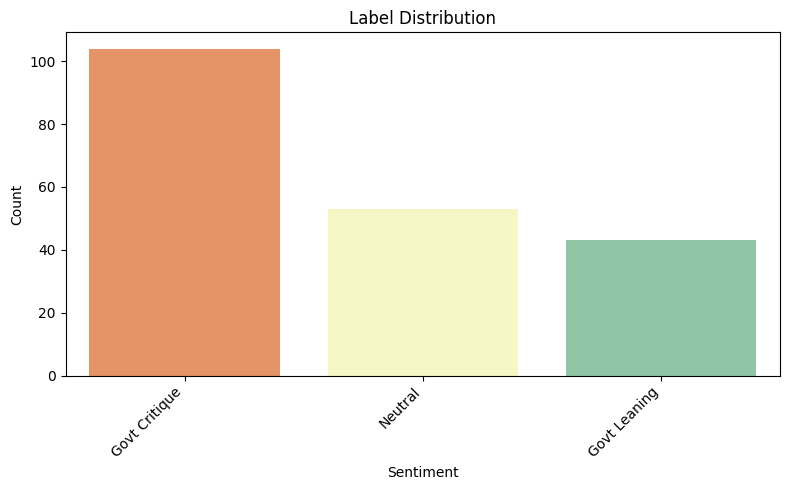

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Political_Bias/Dataset.csv')

df['FINAL LABEL'] = df['FINAL LABEL'].str.strip()
df['FINAL LABEL'] = df['FINAL LABEL'].str.lower()
df['FINAL LABEL'] = df['FINAL LABEL'].str.title()

label_counts = df['FINAL LABEL'].value_counts()
print("Label counts:")
print(label_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='FINAL LABEL', hue='FINAL LABEL', palette='Spectral', dodge=False, legend=False)
plt.title("Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
columns_to_clean = [
    'Annotator 1',
    'Annotator 2 [Zannatul]',
    'Annotator 3-MIM',
    'FINAL LABEL',
    'Article Label',
    'image label'
]

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().str.title()
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

print("Cleaned label columns in df:")
print(df[columns_to_clean].head())

Cleaned label columns in df:
     Annotator 1 Annotator 2 [Zannatul] Annotator 3-MIM    FINAL LABEL  \
0  Govt Critique          Govt Critique   Govt Critique  Govt Critique   
1  Govt Critique          Govt Critique   Govt Critique  Govt Critique   
2  Govt Critique          Govt Critique   Govt Critique  Govt Critique   
3            Nan          Govt Critique   Govt Critique  Govt Critique   
4            Nan                Neutral         Neutral        Neutral   

   Article Label    image label  
0        Neutral  Govt Critique  
1  Govt Critique  Govt Critique  
2            Nan            Nan  
3  Govt Critique        Neutral  
4        Neutral        Neutral  


In [ ]:
print("\nValue counts for cleaned label columns:")
for col in columns_to_clean:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts())
    else:
        print(f"Warning: Column '{col}' not found for value counts.")


Value counts for cleaned label columns:

--- Annotator 1 ---
Annotator 1
Nan              168
Govt Critique     19
Govt Leaning       9
Neutral            4
Name: count, dtype: int64

--- Annotator 2 [Zannatul] ---
Annotator 2 [Zannatul]
Govt Critique    104
Neutral           56
Govt Leaning      39
Nan                1
Name: count, dtype: int64

--- Annotator 3-MIM ---
Annotator 3-MIM
Govt Critique    91
Neutral          71
Govt Leaning     37
Nan               1
Name: count, dtype: int64

--- FINAL LABEL ---
FINAL LABEL
Govt Critique    104
Neutral           53
Govt Leaning      43
Name: count, dtype: int64

--- Article Label ---
Article Label
Govt Critique    72
Neutral          60
Nan              41
Govt Leaning     27
Name: count, dtype: int64

--- image label ---
image label
Neutral          106
Nan               45
Govt Critique     41
Govt Leaning       8
Name: count, dtype: int64


In [ ]:
output_path = '/content/drive/MyDrive/Political_Bias/Political_Bias_Cleaned_Dataset.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: /content/drive/MyDrive/Political_Bias/Political_Bias_Cleaned_Dataset.csv


In [ ]:
!pip install emoji

import re
import pandas as pd
import unicodedata
import emoji

def replace_emoji_with_text(text):
    return emoji.demojize(text, delimiters=(" ", " "))

def remove_urls_hashtags_html(text):
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'#\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    return text

def remove_non_bengali(text):
    return re.sub(r'[^\u0980-\u09FF\s\n]', ' ', text)

def normalize_whitespace(text):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n+', '\n', text)
    return text.strip()

def normalize_unicode(text):
    return unicodedata.normalize('NFKC', text)

def basic_preprocess(text):
    text = str(text)

    text = replace_emoji_with_text(text)
    text = remove_urls_hashtags_html(text)
    text = remove_non_bengali(text)
    text = normalize_unicode(text)
    text = normalize_whitespace(text)

    return text

input_path = '/content/drive/MyDrive/Political_Bias/Political_Bias_Cleaned_Dataset.csv'
output_path = '/content/drive/MyDrive/Political_Bias/Preprocesing.csv'

df = pd.read_csv(input_path)
df['Preprocessed_Text'] = df['Title'].apply(basic_preprocess)
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print("Preprocessing complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.3 MB/s eta 0:00:00
Preprocessing complete.


In [ ]:
import pandas as pd

input_path = '/content/drive/MyDrive/Political_Bias/Preprocesing.csv'
output_path = '/content/drive/MyDrive/Political_Bias/Preprocesing_Cleaned.csv'
df = pd.read_csv(input_path)
columns_to_drop = [
    'Date',
    'Annotator 1',
    'Annotator 2 [Zannatul]',
    'Annotator 3-MIM',
    'NB',
    'Unnamed: 14',
    'Unnamed: 15',
    'Unnamed: 16', 'FINAL_LABEL_NUM',	'Article Label_NUM',	'image label_NUM',	'Annotator 1_NUM',	'Annotator 2 [Zannatul]_NUM',	'Annotator 3-MIM_NUM',	'FINAL LABEL_NUM'
]

df = df.drop(columns=columns_to_drop, errors='ignore')

df.to_csv(output_path, index=False, encoding='utf-8-sig')
print("Columns dropped successfully.")

Columns dropped successfully.


In [ ]:
import pandas as pd

input_path = '/content/drive/MyDrive/Political_Bias/Preprocesing_Cleaned.csv'
output_path = '/content/drive/MyDrive/Political_Bias/Final_Dataset.csv'
df = pd.read_csv(input_path)
label_map = {
    'Govt Critique': 0,
    'Neutral': 1,
    'Govt Leaning': 2
}

label_columns = [
    'Article Label',
    'image label',
    'FINAL LABEL'
]

for col in label_columns:
    df[col] = df[col].map(label_map)

df.to_csv(output_path, index=False, encoding='utf-8-sig')
print("Numerical label conversion complete.")

Numerical label conversion complete.


In [ ]:
import pandas as pd

input_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
df = pd.read_csv(input_path)

print("Original dataset shape:", df.shape)
df_cleaned = df.drop_duplicates(subset=['Title', 'Preprocessed_Text'], keep='first').reset_index(drop=True)
print("After removing duplicates:")
print("Dataset shape:", df_cleaned.shape)
duplicates_removed = len(df) - len(df_cleaned)
print(f"Number of duplicate rows removed: {duplicates_removed}")

output_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
df_cleaned.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Cleaned dataset saved to: {output_path}")

Original dataset shape: (200, 11)
After removing duplicates:
Dataset shape: (198, 11)
Number of duplicate rows removed: 2
Cleaned dataset saved to: /content/drive/MyDrive/Political_Bias/Final_Dataset.csv


Label counts:
FINAL LABEL
0    103
1     53
2     42
Name: count, dtype: int64


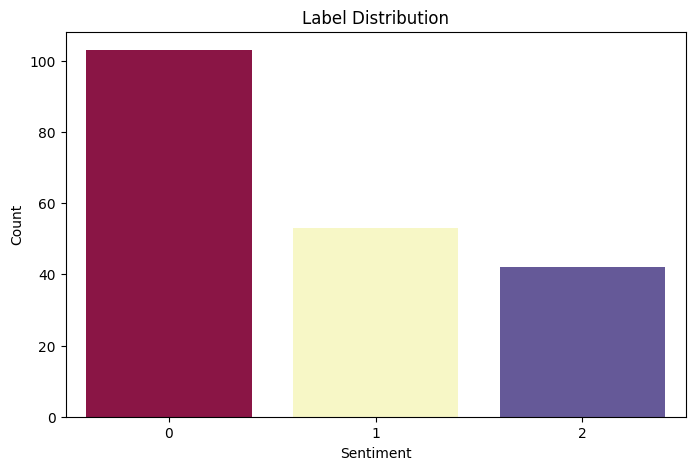

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Political_Bias/Final_Dataset.csv')

label_counts = df['FINAL LABEL'].value_counts()
print("Label counts:")
print(label_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='FINAL LABEL', hue='FINAL LABEL', palette='Spectral', dodge=False, legend=False)
plt.title("Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/drive/MyDrive/Political_Bias/Preprocesing.csv')

annotations = df[['Annotator 1', 'Annotator 2 [Zannatul]', 'Annotator 3-MIM']]

encoder = LabelEncoder()
all_labels = pd.concat([annotations[col] for col in annotations.columns])
encoder.fit(all_labels)

annotations_encoded = annotations.apply(encoder.transform)

n_categories = len(encoder.classes_)
fleiss_matrix = []

for _, row in annotations_encoded.iterrows():
    counts = [0] * n_categories
    for label in row:
        counts[label] += 1
    fleiss_matrix.append(counts)

fleiss_df = pd.DataFrame(fleiss_matrix, columns=encoder.classes_)

kappa_score = fleiss_kappa(fleiss_df.to_numpy())
print("Fleiss' Kappa:", kappa_score)

Fleiss' Kappa: 0.08936907380862955


In [ ]:
!pip install googletrans==4.0.0-rc1

import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from googletrans import Translator
import time

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Final_Dataset.csv")

print("Original dataset shape:", df.shape)
print("\nClass distribution:")
print(df['FINAL LABEL'].value_counts())
print("\nClass mapping:")
print("0: Govt Critique, 1: Neutral, 2: Govt Leaning")

BENGALI_SYNONYMS = {
    'সরকার': ['প্রশাসন', 'রাষ্ট্র', 'কর্তৃপক্ষ', 'গণপ্রশাসন'],
    'বলা': ['উল্লেখ করা', 'জানানো', 'উচ্চারণ করা', 'ঘোষণা করা'],
    'জন্য': ['উদ্দেশ্যে', 'খাতিরে', 'মতো', 'জন্যে'],
    'আর': ['এবং', 'ও', 'পাশাপাশি'],
    'কিন্তু': ['তবে', 'অথচ', 'যদিও'],
    'এখন': ['বর্তমানে', 'এই মুহূর্তে', 'সময়টি'],
    'দেশ': ['রাষ্ট্র', 'জাতি', 'ভূমি', 'দেশজ'],
    'মানুষ': ['ব্যক্তি', 'লোক', 'জন', 'নাগরিক'],
    'সমস্যা': ['কষ্ট', 'দুর্দশা', 'বিপত্তি', 'সমঝোতা'],
    'সমাধান': ['ফলাফল', 'মীমাংসা', 'উপায়'],
    'প্রধান': ['মুখ্য', 'প্রথম', 'গুরুত্বপূর্ণ', 'অগ্রণী'],
    'বিশেষ': ['অসাধারণ', 'অন্যন্য', 'বিশিষ্ট'],
    'নতুন': ['তাজা', 'সদ্য', 'আধুনিক', 'নবীন'],
    'ভাল': ['উত্তম', 'চমৎকার', 'সুন্দর', 'দারুণ'],
    'খারাপ': ['অসুন্দর', 'অনুচিত', 'দুষ্ট'],
    'বড়': ['বৃহৎ', 'বিশাল', 'প্রচণ্ড'],
    'ছোট': ['ক্ষুদ্র', 'সামান্য', 'সঙ্কীর্ণ'],
    'দেয়': ['প্রদান করে', 'হস্তান্তর করে', 'দিতে পারে'],
    'নেয়': ['গ্রহণ করে', 'লয়', 'নিয়েছে'],
    'অপরাধ': ['অন্যায়', 'দোষ', 'অপরাধমূলক'],
    'অর্থনীতি': ['অর্থনৈতিক ব্যবস্থা', 'বাণিজ্য ব্যবস্থা'],
    'শিক্ষা': ['শিক্ষাব্যবস্থা', 'পাঠদান'],
    'সেবা': ['পরিষেবা', 'সুবিধা'],
}

def bengali_synonym_replacement(text, replace_prob=0.15):
    words = text.split()
    for i, word in enumerate(words):
        if len(word) > 2 and word in BENGALI_SYNONYMS and random.random() < replace_prob:
            synonym = random.choice(BENGALI_SYNONYMS[word])
            if synonym != word:
                words[i] = synonym
    return ' '.join(words)

def bengali_random_deletion(text, delete_prob=0.1):
    words = text.split()
    if len(words) > 4:
        new_words = [word for word in words if random.random() > delete_prob * (1 - len(word)/10)]
        if len(new_words) >= 3:
            return ' '.join(new_words)
    return text

def bengali_random_swap(text, swap_prob=0.15):
    words = text.split()
    if len(words) >= 4:
        num_swaps = max(1, int(len(words) * swap_prob))
        for _ in range(num_swaps):
            idx = random.randint(0, len(words)-2)
            words[idx], words[idx+1] = words[idx+1], words[idx]
    return ' '.join(words)

def bengali_random_insertion(text, insert_prob=0.1):
    filler_words = ['এবং', 'অথবা', 'কিন্তু', 'তবে', 'যেমন', 'এখন', 'আর', 'অথচ', 'সাথে']
    words = text.split()
    if len(words) > 3:
        num_insertions = max(1, int(len(words) * insert_prob))
        for _ in range(num_insertions):
            words.insert(random.randint(0, len(words)), random.choice(filler_words))
    return ' '.join(words)

def bengali_back_translation(text):
    try:
        translator = Translator()
        time.sleep(0.5)
        translated = translator.translate(text, src='bn', dest='en')
        time.sleep(0.5)
        back_translated = translator.translate(translated.text, src='en', dest='bn')
        return back_translated.text
    except:
        return text

def augment_bengali_text(text, augmentation_type='all'):
    if pd.isna(text) or len(text.strip()) < 10:
        return text
    augmented = text
    if augmentation_type == 'all':
        augmentations = [bengali_synonym_replacement, bengali_random_swap, bengali_random_deletion, bengali_random_insertion]
        random.shuffle(augmentations)
        for aug_func in augmentations[:2]:
            augmented = aug_func(augmented)
    elif augmentation_type == 'synonym':
        augmented = bengali_synonym_replacement(augmented)
    elif augmentation_type == 'back_translation':
        augmented = bengali_back_translation(augmented)
    elif augmentation_type == 'swap':
        augmented = bengali_random_swap(augmented)
    return augmented.strip()

def balance_dataset_with_augmentation(df, target_column='FINAL LABEL', text_column='Preprocessed_Text', target_size=104):
    balanced_samples = []
    existing_texts = set(df[text_column].tolist())

    for class_label in sorted(df[target_column].unique()):
        class_data = df[df[target_column] == class_label]
        current_count = len(class_data)
        needed_count = max(0, target_size - current_count)

        for _, row in class_data.iterrows():
            balanced_samples.append({
                'Title': row['Title'],
                'Preprocessed_Text': row[text_column],
                'FINAL LABEL': row[target_column],
                'is_augmented': False,
                'source_index': _
            })

        if needed_count > 0:
            strategies = ['synonym', 'swap', 'all']
            for _ in range(needed_count):
                source_row = class_data.sample(n=1).iloc[0]
                strategy = random.choice(strategies)
                augmented_text = augment_bengali_text(source_row[text_column], strategy)

                attempts = 0
                while augmented_text in existing_texts and attempts < 10:
                    strategy = random.choice(strategies)
                    augmented_text = augment_bengali_text(source_row[text_column], strategy)
                    attempts += 1

                # Force small random insertion if still duplicate
                if augmented_text in existing_texts:
                    augmented_text += ' ' + random.choice(list(BENGALI_SYNONYMS.keys()))

                existing_texts.add(augmented_text)
                balanced_samples.append({
                    'Title': f"[Augmented] {source_row['Title']}",
                    'Preprocessed_Text': augmented_text,
                    'FINAL LABEL': source_row[target_column],
                    'is_augmented': True,
                    'source_index': source_row.name,
                    'augmentation_strategy': strategy
                })

    balanced_df = pd.DataFrame(balanced_samples).sample(frac=1, random_state=42).reset_index(drop=True)
    return balanced_df

target_size = 104
balanced_df = balance_dataset_with_augmentation(df, target_size=target_size)

balanced_df = balanced_df.drop_duplicates(subset=['Preprocessed_Text']).reset_index(drop=True)

print("\nBalanced dataset shape:", balanced_df.shape)
print("Balanced class distribution:\n", balanced_df['FINAL LABEL'].value_counts())
print("Total augmented samples:", balanced_df['is_augmented'].sum())

output_path = "/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv"
balanced_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Dataset saved to: {output_path}")

train_df, temp_df = train_test_split(balanced_df, test_size=0.3, random_state=42, stratify=balanced_df['FINAL LABEL'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['FINAL LABEL'])

train_df.to_csv("/content/drive/MyDrive/Political_Bias/train_set.csv", index=False, encoding='utf-8-sig')
val_df.to_csv("/content/drive/MyDrive/Political_Bias/val_set.csv", index=False, encoding='utf-8-sig')
test_df.to_csv("/content/drive/MyDrive/Political_Bias/test_set.csv", index=False, encoding='utf-8-sig')

print("Training set:", len(train_df), "Validation set:", len(val_df), "Test set:", len(test_df))

Original dataset shape: (198, 11)

Class distribution:
FINAL LABEL
0    103
1     53
2     42
Name: count, dtype: int64

Class mapping:
0: Govt Critique, 1: Neutral, 2: Govt Leaning

Balanced dataset shape: (312, 6)
Balanced class distribution:
 FINAL LABEL
2    104
0    104
1    104
Name: count, dtype: int64
Total augmented samples: 114
Dataset saved to: /content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv
Training set: 218 Validation set: 47 Test set: 47


In [ ]:
import pandas as pd
file_path = "/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv"
df = pd.read_csv(file_path)
title_duplicates = df[df.duplicated(subset=['Title'], keep=False)]
print(f"Number of duplicate Titles: {len(title_duplicates)}")
if not title_duplicates.empty:
    print(title_duplicates[['Title', 'Preprocessed_Text']])
text_duplicates = df[df.duplicated(subset=['Preprocessed_Text'], keep=False)]
print(f"\nNumber of duplicate Preprocessed_Text: {len(text_duplicates)}")
if not text_duplicates.empty:
    print(text_duplicates[['Title', 'Preprocessed_Text']])

Number of duplicate Titles: 83
                                                 Title  \
11   [Augmented] সোমবার নয়, বৃহস্পতিবার থেকে সারাদে...   
14   [Augmented] সাংবাদিক রোজিনার জামিননামা-পাসপোর্...   
19   [Augmented] রামপাল তাপবিদ্যুৎ কেন্দ্রে বাণিজ্য...   
21   [Augmented] শ্রম ভবনে ত্রিপক্ষীয় সভা\n\nপোশাক ...   
28   [Augmented] ধর্ষণের সর্বোচ্চ শাস্তি মৃত্যুদণ্ড...   
..                                                 ...   
296  [Augmented] ধর্ষণের সর্বোচ্চ শাস্তি মৃত্যুদণ্ড...   
297  [Augmented] রোহিঙ্গা' ও 'শরণার্থী' বলবে না বাং...   
305  [Augmented] শ্রম ভবনে ত্রিপক্ষীয় সভা\n\nপোশাক ...   
307  [Augmented] গোপালগঞ্জে সহিংস পরিস্থিতি তৈরি হও...   
310  [Augmented] খালেদা জিয়াকে ঘিরে মানুষের ভালোবাস...   

                                     Preprocessed_Text  
11    সোমবার বৃহস্পতিবার নয় থেকে সারাদেশে কঠোর লকডাউন  
14    সাংবাদিক রোজিনার জামিননামা পাসপোর্ট কিন্তু দাখিল  
19   রামপাল তাপবিদ্যুৎ কেন্দ্রে বাণিজ্যিক উৎপাদন শু...  
21   শ্রম ভবনে কিন্তু ত্রিপক্ষীয় সভা পোশাক 

Train/Val/Test sizes: 218 47 47


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Accuracy: 0.723404255319149
Precision: 0.7191951566951568
Recall: 0.7277777777777779
F1 Score: 0.7188915012190874
               precision    recall  f1-score   support

Govt Critique       0.69      0.56      0.62        16
      Neutral       0.78      0.93      0.85        15
 Govt Leaning       0.69      0.69      0.69        16

     accuracy                           0.72        47
    macro avg       0.72      0.73      0.72        47
 weighted avg       0.72      0.72      0.72        47



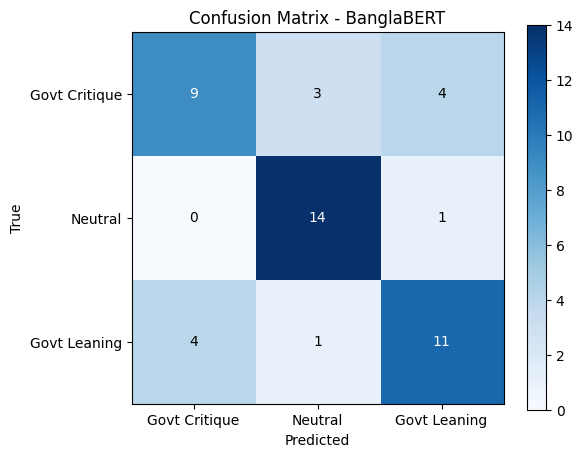

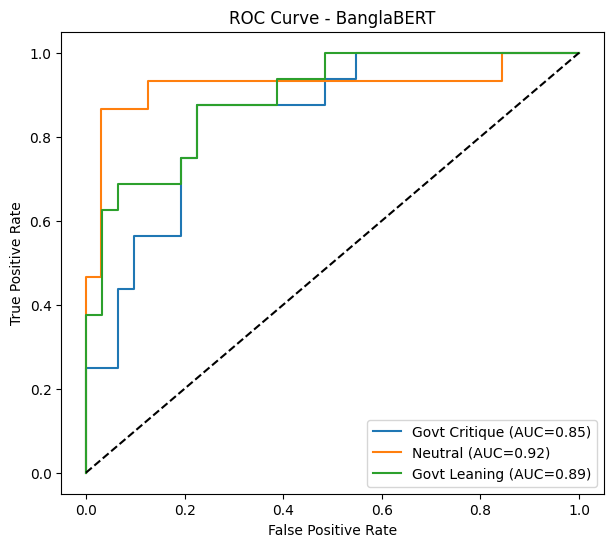

Predictions saved to: /content/drive/MyDrive/Political_Bias/BanglaBERT.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from scipy.special import softmax

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['FINAL LABEL'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['FINAL LABEL'],
    random_state=42
)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

model_name = "sagorsarker/bangla-bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

def tokenize(batch):
    return tokenizer(
        batch["Preprocessed_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("FINAL LABEL", "labels")
val_ds = val_ds.rename_column("FINAL LABEL", "labels")
test_ds = test_ds.rename_column("FINAL LABEL", "labels")

cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Political_Bias/banglabert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=50,
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer)
)

trainer.train()

predictions = trainer.predict(test_ds)

logits = predictions.predictions
y_true = test_df['FINAL LABEL'].values
y_pred = np.argmax(logits, axis=1)
y_prob = softmax(logits, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Govt Critique", "Neutral", "Govt Leaning"]
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
classes = ["Govt Critique", "Neutral", "Govt Leaning"]
plt.xticks([0,1,2], classes)
plt.yticks([0,1,2], classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - BanglaBERT")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.show()

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(7,6))
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BanglaBERT")
plt.legend()
plt.show()

test_df['banglabert'] = y_pred
output_path = "/content/drive/MyDrive/Political_Bias/BanglaBERT.csv"
test_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Predictions saved to: {output_path}")

Train/Val/Test sizes: 218 47 47


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: monsoon-nlp/bangla-electra
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/218 [00:00<?, ? examples/s]

Map:   0%|          | 0/47 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

Accuracy: 0.46808510638297873
Precision: 0.4681818181818182
Recall: 0.46527777777777773
F1 Score: 0.4615384615384615
               precision    recall  f1-score   support

Govt Critique       0.45      0.56      0.50        16
      Neutral       0.45      0.33      0.38        15
 Govt Leaning       0.50      0.50      0.50        16

     accuracy                           0.47        47
    macro avg       0.47      0.47      0.46        47
 weighted avg       0.47      0.47      0.46        47



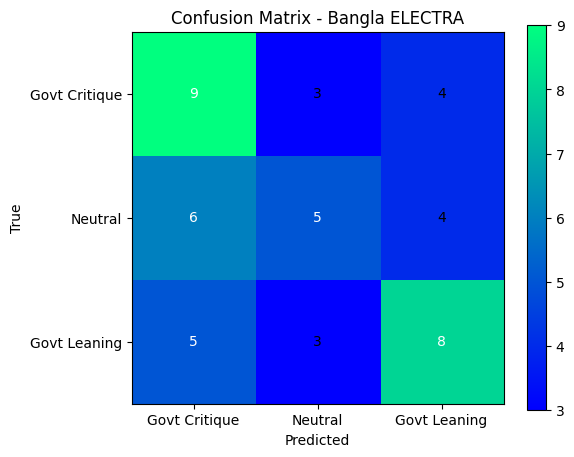

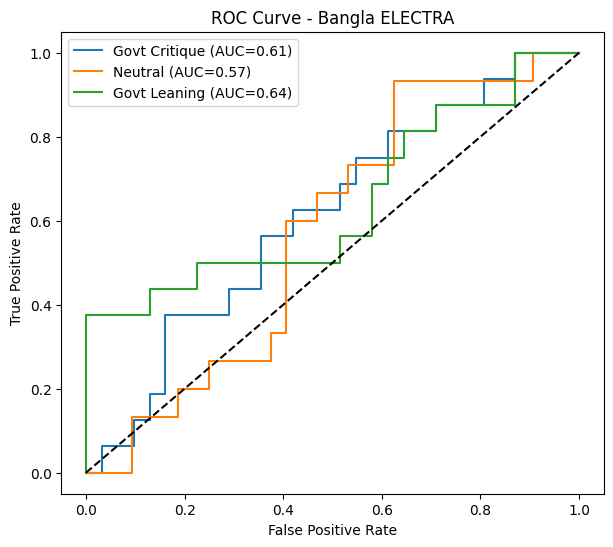

Predictions saved to: /content/drive/MyDrive/Political_Bias/BanglaELECTRA_Predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from scipy.special import softmax

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

# Train/Val/Test split
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['FINAL LABEL'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['FINAL LABEL'],
    random_state=42
)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

# Model and tokenizer
model_name = "monsoon-nlp/bangla-electra"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

# Tokenization function
def tokenize(batch):
    return tokenizer(
        batch["Preprocessed_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

# Prepare datasets
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("FINAL LABEL", "labels")
val_ds = val_ds.rename_column("FINAL LABEL", "labels")
test_ds = test_ds.rename_column("FINAL LABEL", "labels")

cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

# Training arguments
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Political_Bias/bangla-electra",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=50,
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer)
)

# Train
trainer.train()

# Predictions
predictions = trainer.predict(test_ds)
logits = predictions.predictions
y_true = test_df['FINAL LABEL'].values
y_pred = np.argmax(logits, axis=1)
y_prob = softmax(logits, axis=1)

# Metrics
classes = ["Govt Critique", "Neutral", "Govt Leaning"]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='winter')
plt.colorbar()
plt.xticks([0,1,2], classes)
plt.yticks([0,1,2], classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Bangla ELECTRA")
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.show()

# ROC Curve
y_true_bin = label_binarize(y_true, classes=[0,1,2])
plt.figure(figsize=(7,6))
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bangla ELECTRA")
plt.legend()
plt.show()

# Save predictions
test_df['bangla_electra'] = y_pred
output_path = "/content/drive/MyDrive/Political_Bias/BanglaELECTRA_Predictions.csv"
test_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Predictions saved to: {output_path}")


Train/Val/Test sizes: 218 47 47


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Accuracy: 0.6382978723404256
Precision: 0.6734006734006734
Recall: 0.6388888888888888
F1 Score: 0.6485671191553545
               precision    recall  f1-score   support

Govt Critique       0.50      0.56      0.53        16
      Neutral       0.91      0.67      0.77        15
 Govt Leaning       0.61      0.69      0.65        16

     accuracy                           0.64        47
    macro avg       0.67      0.64      0.65        47
 weighted avg       0.67      0.64      0.65        47



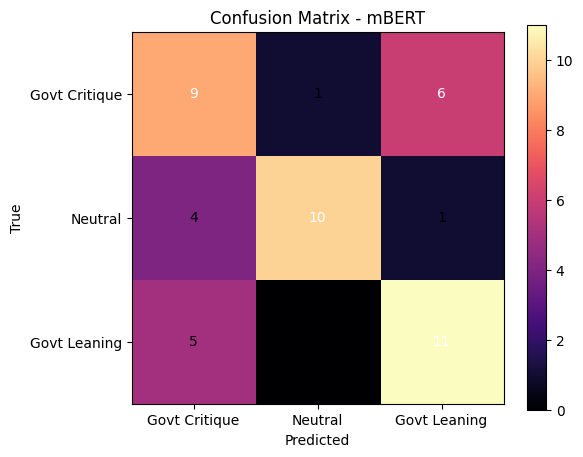

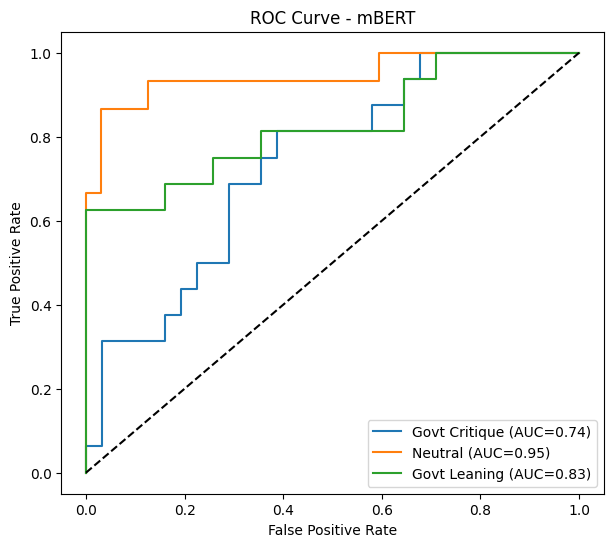

Predictions saved to: /content/drive/MyDrive/Political_Bias/mBERT_Predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
from scipy.special import softmax

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['FINAL LABEL'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['FINAL LABEL'],
    random_state=42
)

print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

def tokenize(batch):
    return tokenizer(
        batch["Preprocessed_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("FINAL LABEL", "labels")
val_ds = val_ds.rename_column("FINAL LABEL", "labels")
test_ds = test_ds.rename_column("FINAL LABEL", "labels")

cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Political_Bias/mbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=50,
    fp16=True,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer)
)

trainer.train()

predictions = trainer.predict(test_ds)

logits = predictions.predictions
y_true = test_df['FINAL LABEL'].values
y_pred = np.argmax(logits, axis=1)
y_prob = softmax(logits, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

classes = ["Govt Critique", "Neutral", "Govt Leaning"]
print(classification_report(
    y_true,
    y_pred,
    target_names=classes
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='magma')
plt.colorbar()
plt.xticks([0,1,2], classes)
plt.yticks([0,1,2], classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - mBERT")

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.show()

y_true_bin = label_binarize(y_true, classes=[0,1,2])
plt.figure(figsize=(7,6))
for i, label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - mBERT")
plt.legend()
plt.show()

test_df['mbert'] = y_pred
output_path = "/content/drive/MyDrive/Political_Bias/mBERT_Predictions.csv"
test_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Predictions saved to: {output_path}")


Accuracy: 0.7301587301587301
Precision: 0.7301587301587302
Recall: 0.7301587301587302
F1 Score: 0.7301587301587302


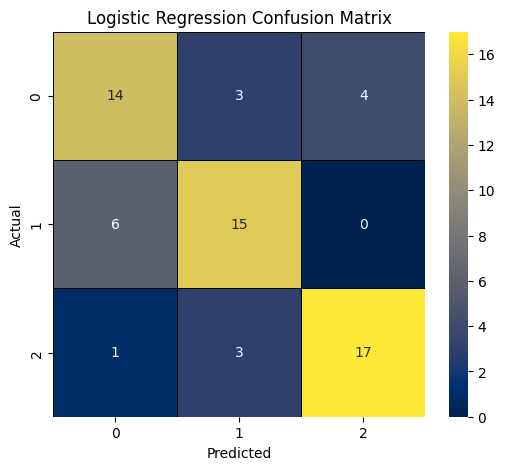

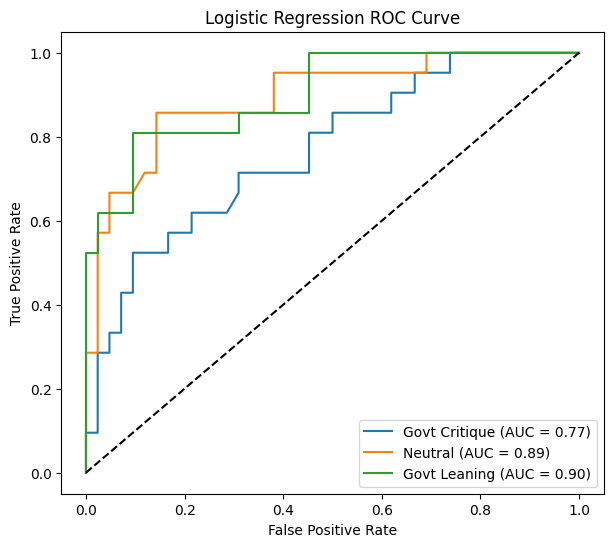

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis", linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.746031746031746
Precision: 0.7486291486291486
Recall: 0.746031746031746
F1 Score: 0.7470581350331775


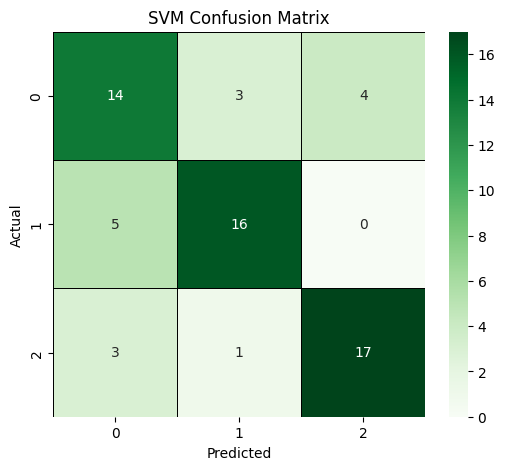

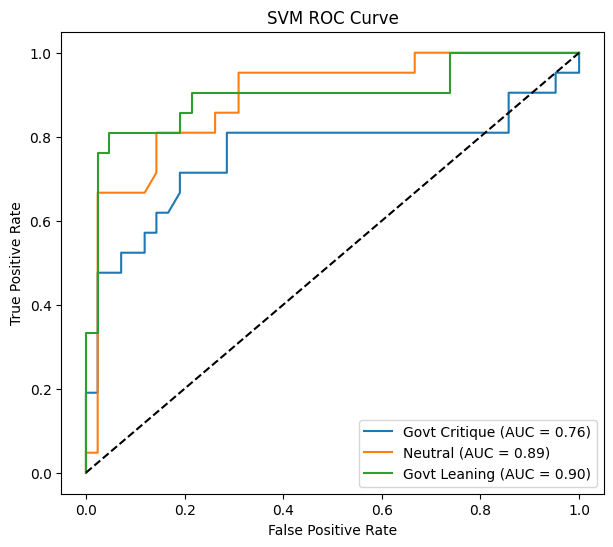

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = SVC(kernel="linear", probability=True)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(SVC(kernel="linear", probability=True))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.6825396825396826
Precision: 0.6881130141999708
Recall: 0.6825396825396824
F1 Score: 0.6832908693373808


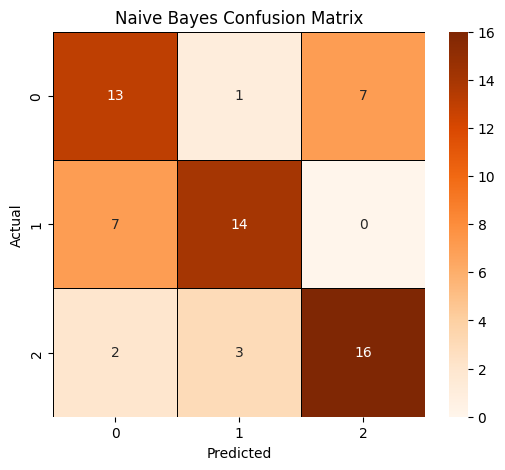

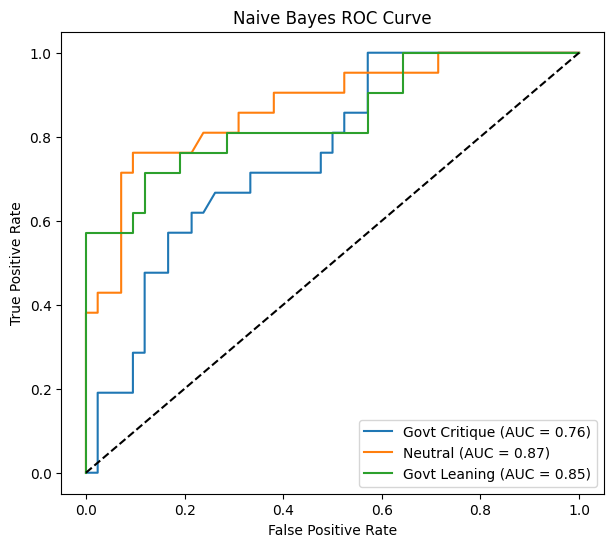

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(MultinomialNB())
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.6666666666666666
Precision: 0.6608391608391608
Recall: 0.6666666666666666
F1 Score: 0.6422872340425533


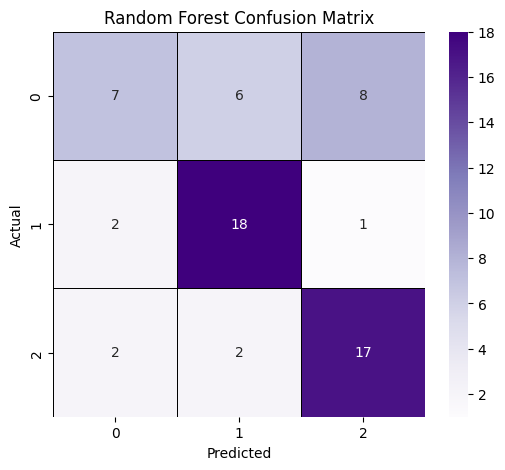

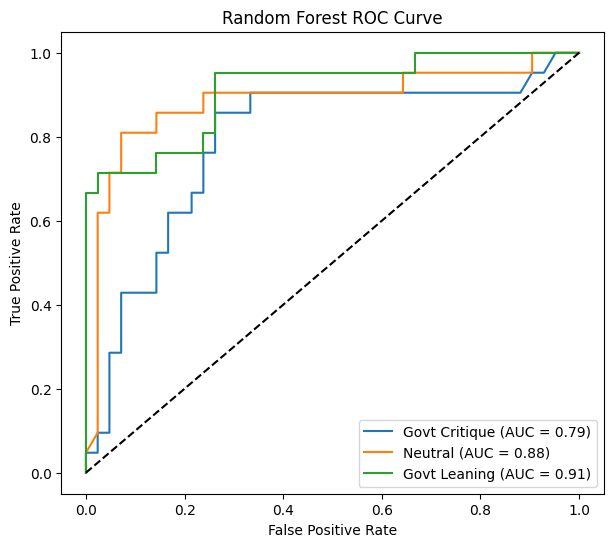

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, random_state=42))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.7301587301587301
Precision: 0.7240596226103472
Recall: 0.7301587301587302
F1 Score: 0.7118241235888295


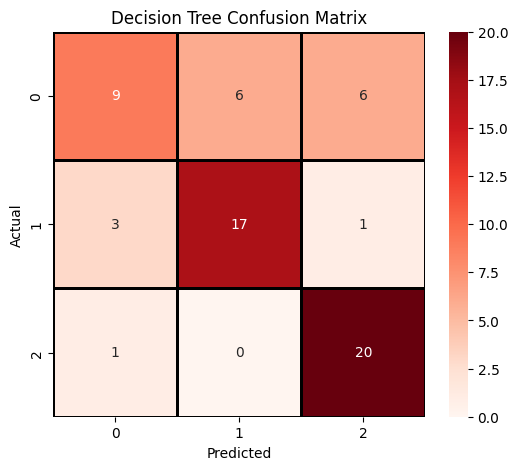

/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:557: RuntimeWarning: invalid value encountered in divide
  Y /= np.sum(Y, axis=1)[:, np.newaxis]


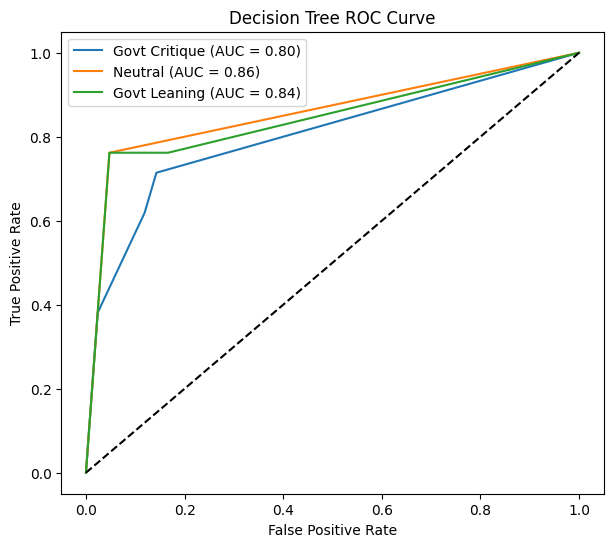

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",linewidths=0.75, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)
y_score = np.nan_to_num(y_score, nan=0.0)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

Accuracy: 0.4603174603174603
Precision: 0.6346031746031745
Recall: 0.4603174603174603
F1 Score: 0.4200263308244529


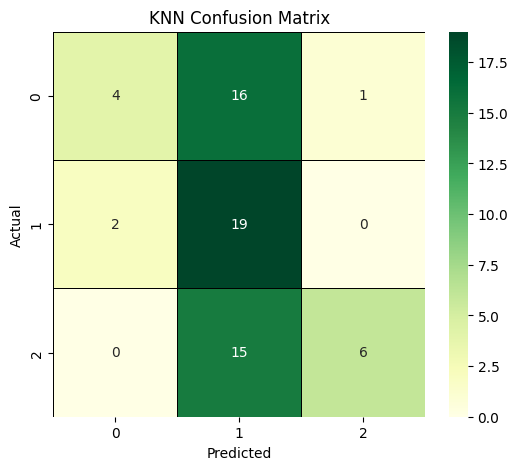

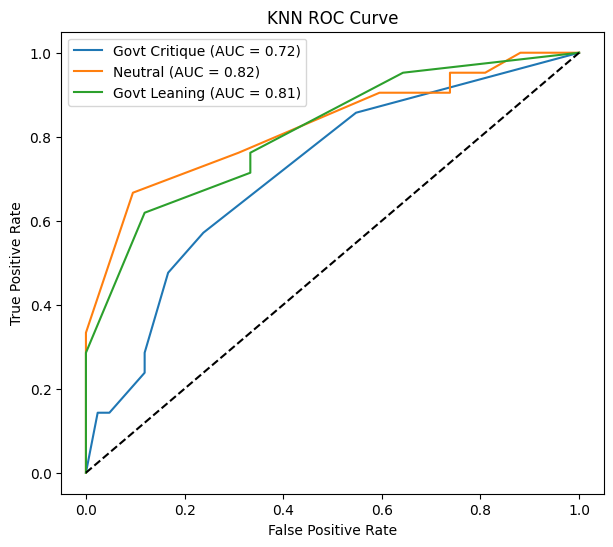

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

df = pd.read_csv("/content/drive/MyDrive/Political_Bias/Balanced_Augmented_Dataset.csv")

X = df["Preprocessed_Text"]
y = df["FINAL LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Precision:", pre)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn",linewidths=0.5, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

y_test_bin = label_binarize(y_test, classes=[0,1,2])
clf = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=7))
y_score = clf.fit(X_train_vec, y_train).predict_proba(X_test_vec)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,6))
plt.plot(fpr[0], tpr[0], label="Govt Critique (AUC = %0.2f)" % roc_auc[0])
plt.plot(fpr[1], tpr[1], label="Neutral (AUC = %0.2f)" % roc_auc[1])
plt.plot(fpr[2], tpr[2], label="Govt Leaning (AUC = %0.2f)" % roc_auc[2])
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

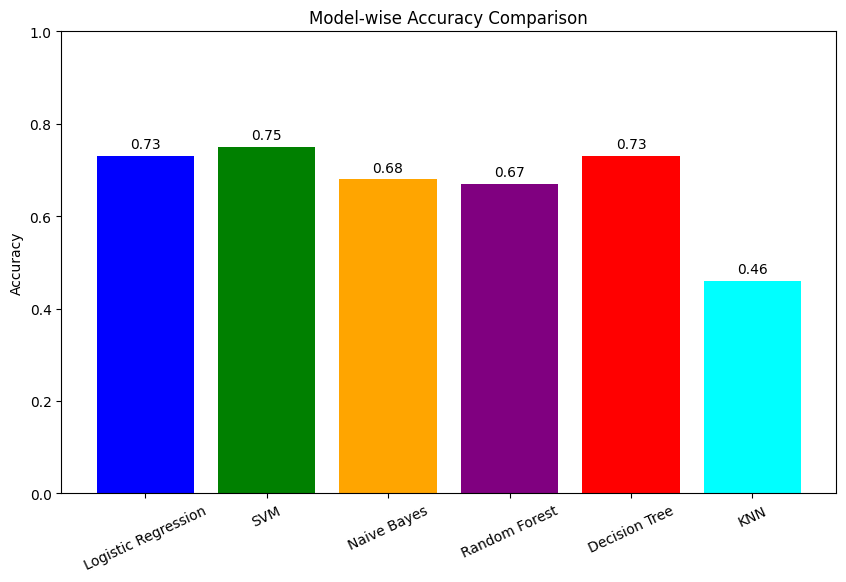

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "SVM",
    "Naive Bayes",
    "Random Forest",
    "Decision Tree",
    "KNN"
]

accuracy = [
    0.73,
    0.75,
    0.68,
    0.67,
    0.73,
    0.46
]

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy, color=["blue", "green", "orange", "purple", "red", "cyan"])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model-wise Accuracy Comparison")
plt.xticks(rotation=25)

for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{acc:.2f}", ha='center', va='bottom')

plt.show()

# **Images**

In [ ]:
!pip install imagehash
!pip install pillow-avif-plugin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.7 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import imagehash

input_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Dataset.csv"
input_image_folder = "/content/drive/MyDrive/Political_Bias/images"
output_image_folder = "/content/drive/MyDrive/Political_Bias/processed_images"
output_csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"

os.makedirs(output_image_folder, exist_ok=True)

df = pd.read_csv(input_csv_path)

hashes = {}
new_data = []

MIN_WIDTH = 100
MIN_HEIGHT = 100

for _, row in tqdm(df.iterrows(), total=len(df)):
    image_id = str(row["Image_id"]).strip()
    final_label = row["FINAL LABEL"]

    image_path = None
    for ext in [".jpg", ".jpeg", ".png", ".webp", ".avif"]:
        temp_path = os.path.join(input_image_folder, image_id + ext)
        if os.path.exists(temp_path):
            image_path = temp_path
            break

    if image_path is None:
        continue

    try:
        img = Image.open(image_path)
    except:
        continue

    if img.width < MIN_WIDTH or img.height < MIN_HEIGHT:
        continue

    try:
        img = img.convert("RGB")
    except:
        continue

    try:
        img_hash = imagehash.phash(img)
        if img_hash in hashes:
            continue
        hashes[img_hash] = image_id
    except:
        continue

    img.thumbnail((256, 256), Image.LANCZOS)

    new_img = Image.new("RGB", (256, 256), (0, 0, 0))
    new_img.paste(
        img,
        ((256 - img.width) // 2, (256 - img.height) // 2)
    )

    new_image_path = os.path.join(output_image_folder, image_id + ".jpg")
    new_img.save(new_image_path, "JPEG", quality=95)

    new_data.append([image_id, new_image_path, final_label])

new_df = pd.DataFrame(new_data, columns=["Image_id", "Image_Path", "Final_Label"])
new_df.to_csv(output_csv_path, index=False)

print("Preprocessing completed.")
print("Saved at:", output_csv_path)

100%|██████████| 198/198 [01:12<00:00,  2.73it/s]

Preprocessing completed.
Saved at: /content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4
Precision: 0.4388888888888889
Recall: 0.4
F1-score: 0.4091339459760512


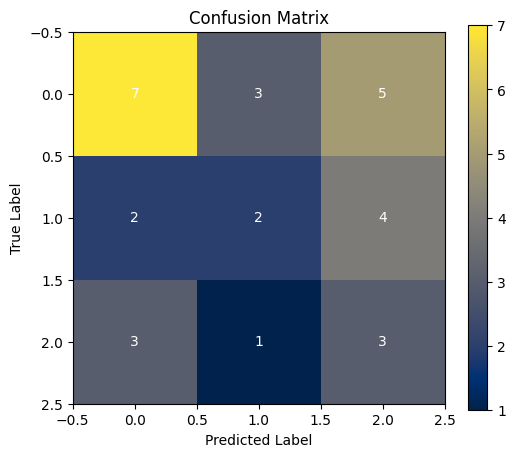

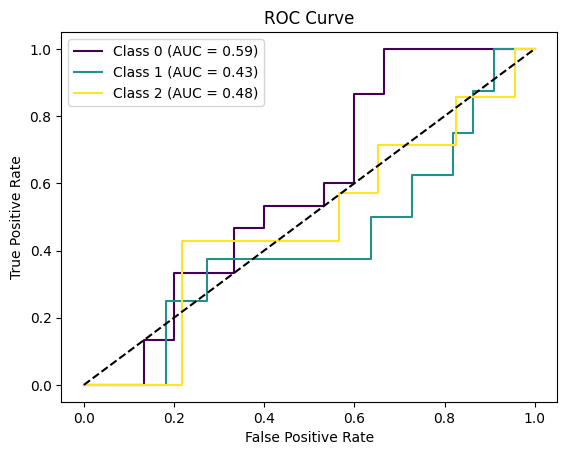

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='cividis')
plt.title("Confusion Matrix")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'white')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#440154', '#21918c', '#fde725']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.36666666666666664
Precision: 0.41028138528138525
Recall: 0.36666666666666664
F1-score: 0.38222222222222224


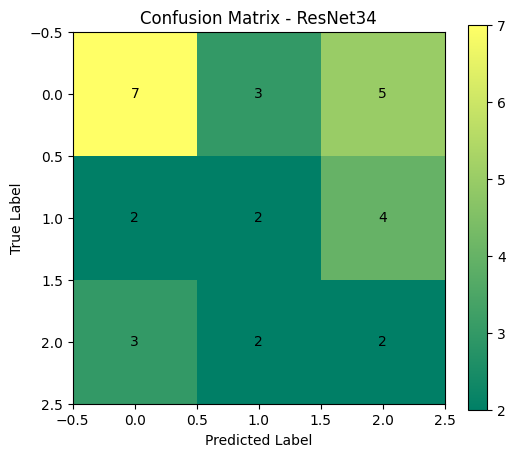

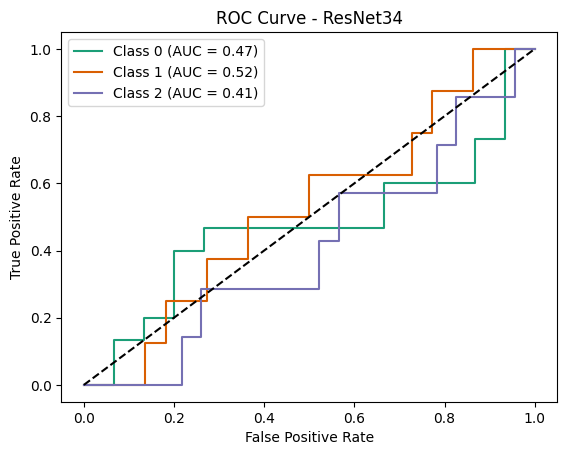

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.resnet34(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='summer')
plt.title("Confusion Matrix - ResNet34")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet34")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3
Precision: 0.3722222222222222
Recall: 0.3
F1-score: 0.3206349206349206


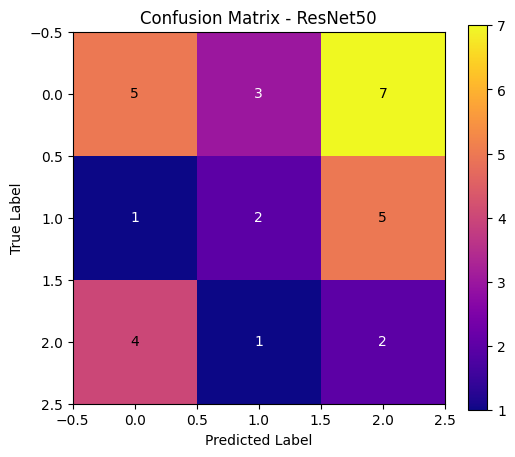

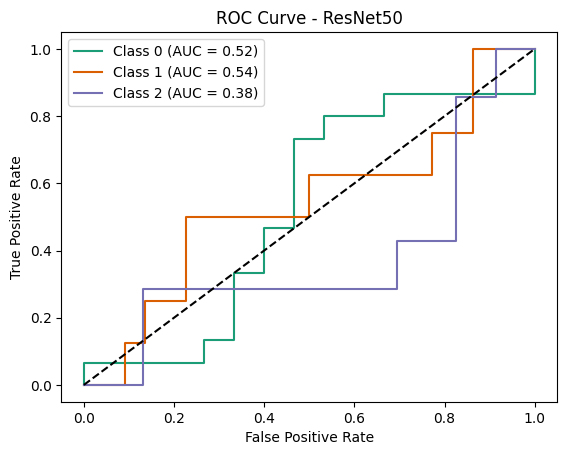

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='plasma')
plt.title("Confusion Matrix - ResNet50")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'white')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet50")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.4666666666666667
Precision: 0.32753623188405795
Recall: 0.4666666666666667
F1-score: 0.38245614035087716


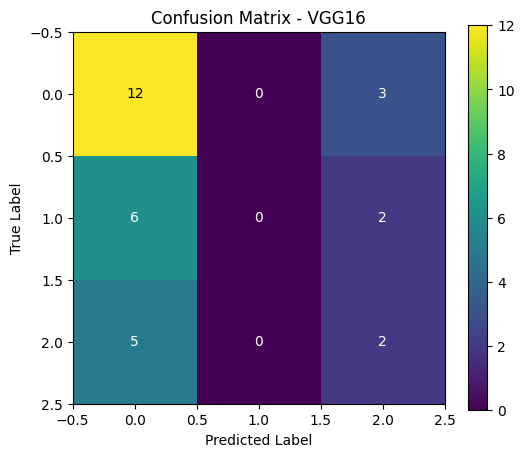

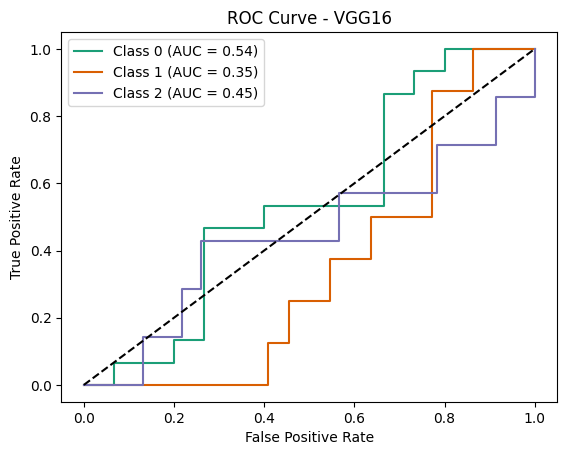

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='viridis')
plt.title("Confusion Matrix - VGG16")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'white')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.36666666666666664
Precision: 0.2391304347826087
Recall: 0.36666666666666664
F1-score: 0.2894736842105263


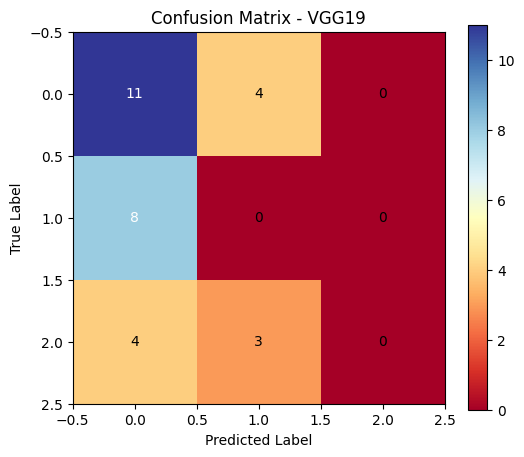

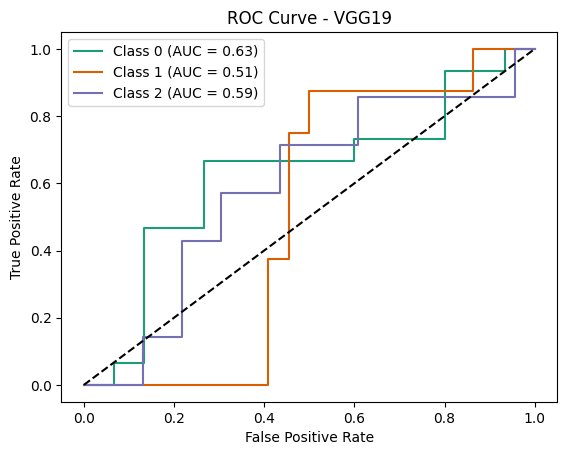

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.vgg19(pretrained=True)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='RdYlBu')
plt.title("Confusion Matrix - VGG19")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG19")
plt.legend()
plt.show()

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 121MB/s]


Accuracy: 0.3333333333333333
Precision: 0.274074074074074
Recall: 0.3333333333333333
F1-score: 0.3007575757575758


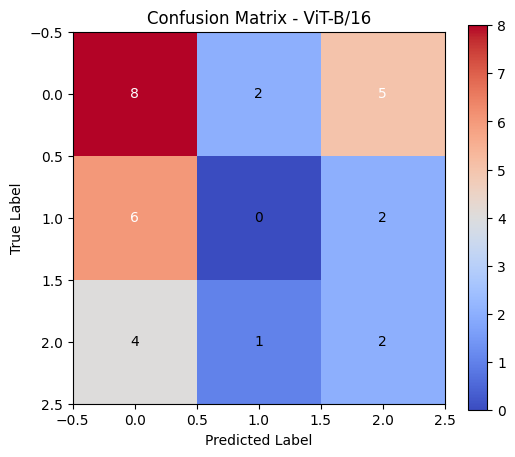

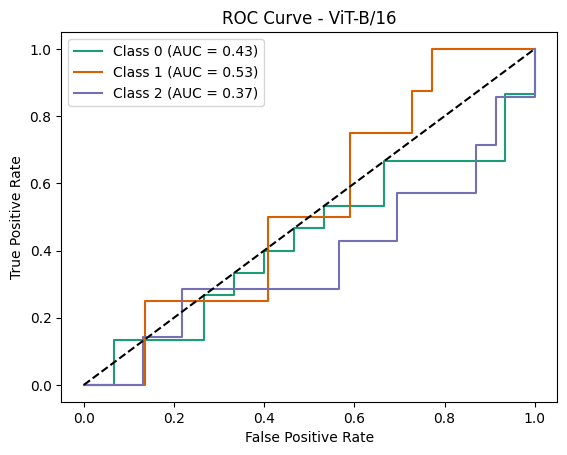

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

weights = ViT_B_16_Weights.DEFAULT
transform = weights.transforms()

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
model.heads.head = nn.Linear(model.heads.head.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='coolwarm')
plt.title("Confusion Matrix - ViT-B/16")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViT-B/16")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.36666666666666664
Precision: 0.33310185185185187
Recall: 0.36666666666666664
F1-score: 0.34865591397849466


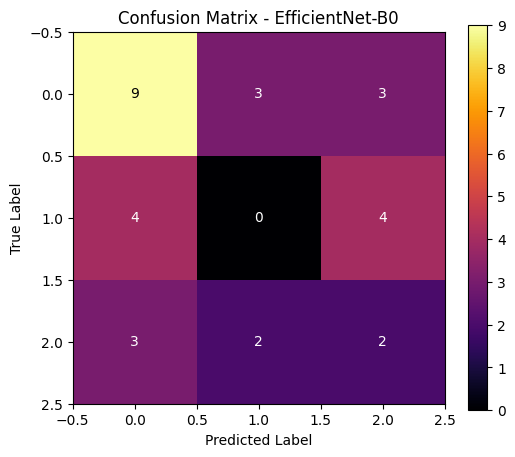

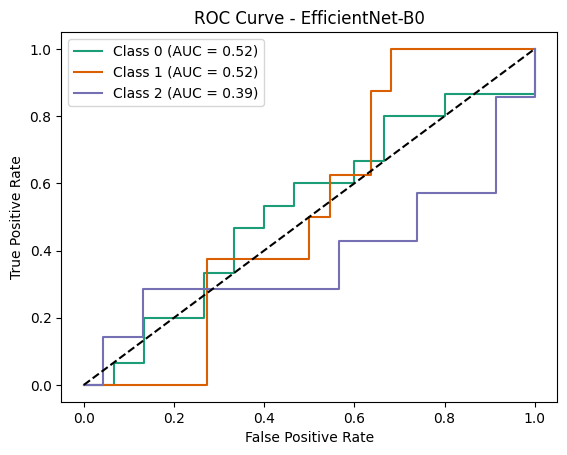

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='inferno')
plt.title("Confusion Matrix - EfficientNet-B0")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='black' if cm[i,j]>cm.max()/2 else 'white')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - EfficientNet-B0")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 123MB/s]


Accuracy: 0.4
Precision: 0.31666666666666665
Recall: 0.4
F1-score: 0.34174174174174177


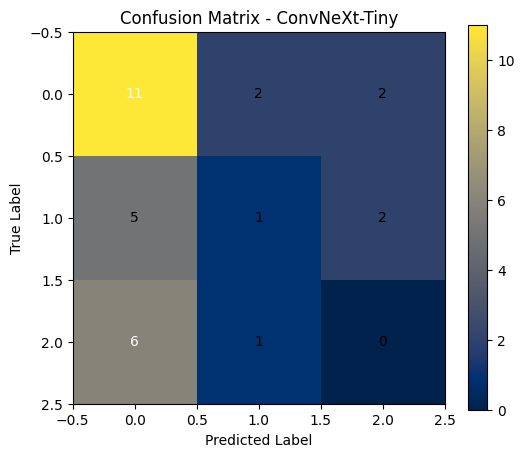

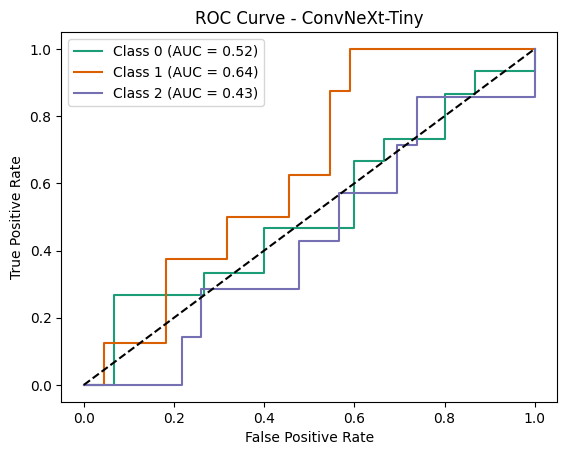

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Final_Label"], random_state=42)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_dataset = CustomDataset(train_df, transform)
test_dataset = CustomDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

model = models.convnext_tiny(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='cividis')
plt.title("Confusion Matrix - ConvNeXt-Tiny")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

y_test_bin = label_binarize(all_labels, classes=[0,1,2])
all_probs = np.array(all_probs)
plt.figure()
colors = ['#1b9e77', '#d95f02', '#7570b3']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ConvNeXt-Tiny")
plt.legend()
plt.show()


--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4000, Precision: 0.4083, Recall: 0.4000, F1-score: 0.3828


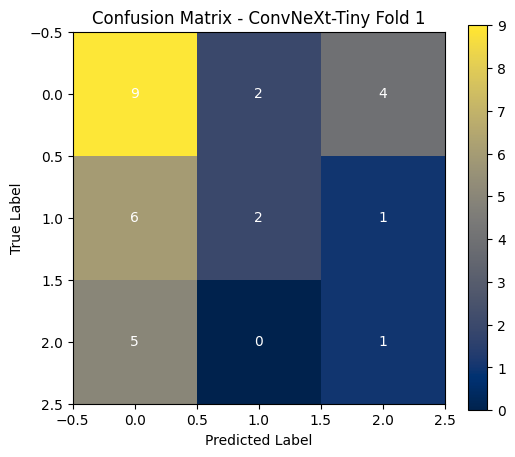

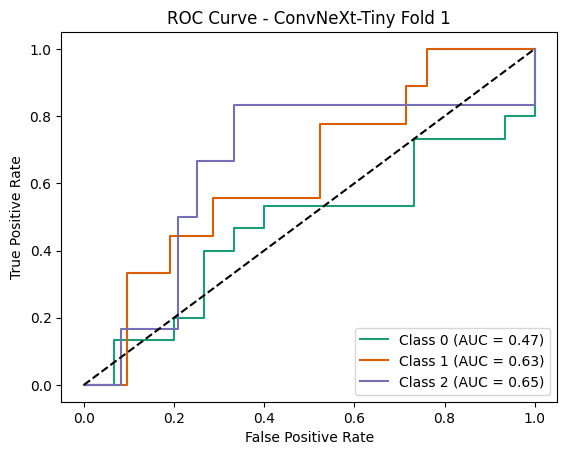


--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.4667, Precision: 0.4219, Recall: 0.4667, F1-score: 0.4278


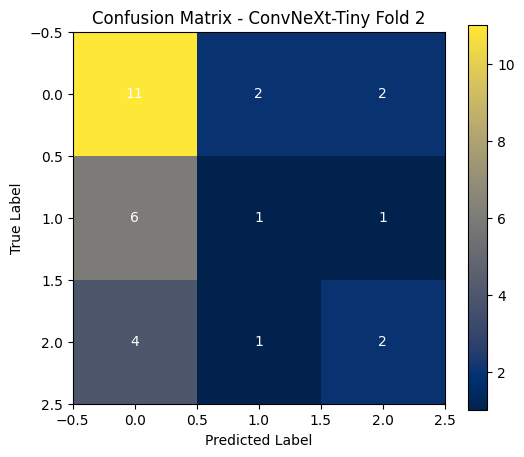

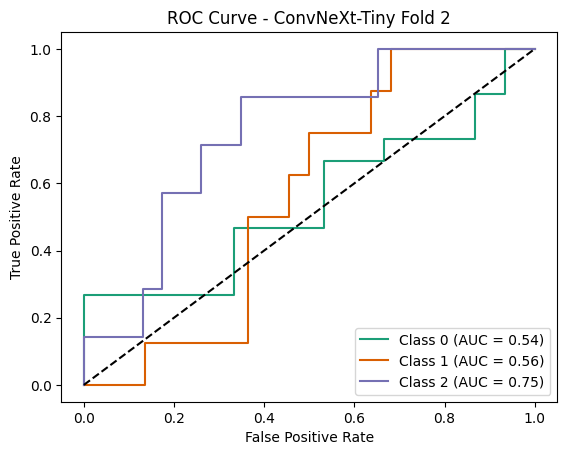


--- Fold 3 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.3667, Precision: 0.3504, Recall: 0.3667, F1-score: 0.3570


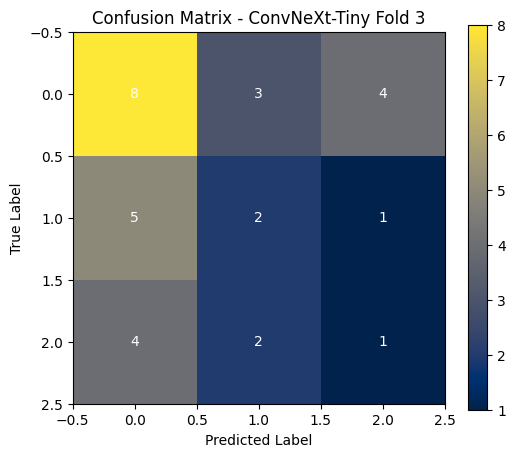

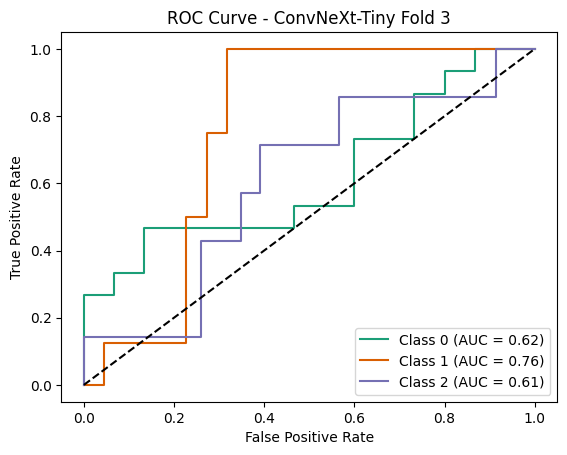


--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.5000, Precision: 0.3752, Recall: 0.5000, F1-score: 0.4225


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


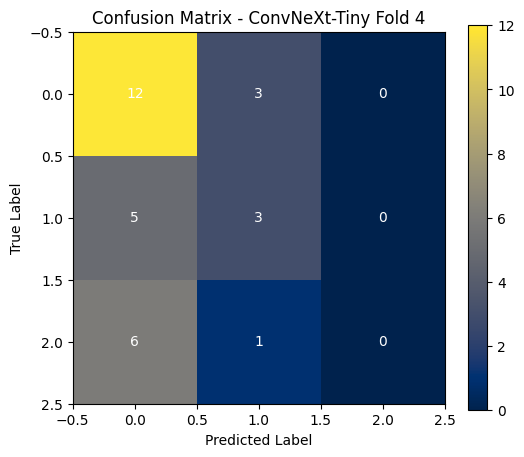

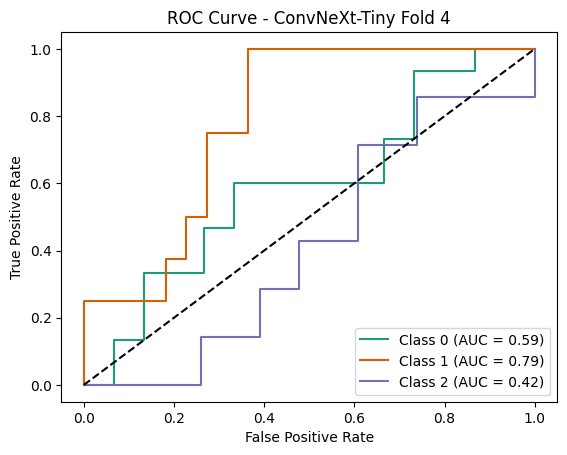


--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy: 0.5517, Precision: 0.5402, Recall: 0.5517, F1-score: 0.5419


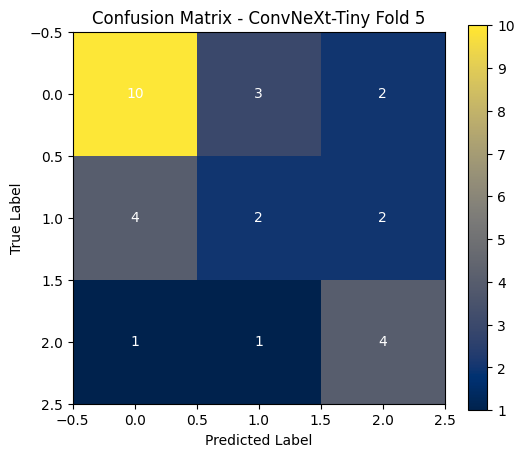

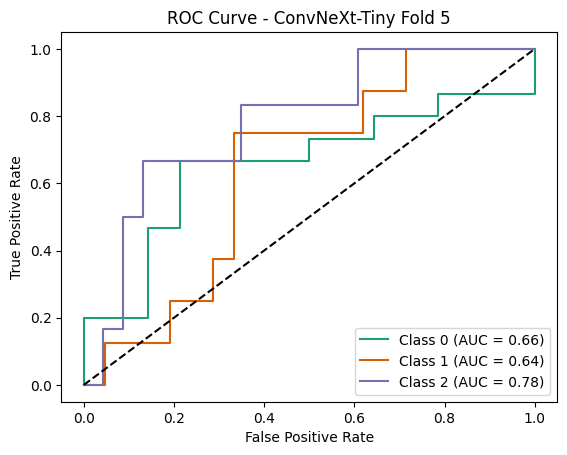


--- K-Fold Summary ---
Average Accuracy: 0.4570
Average Precision: 0.4192
Average Recall: 0.4570
Average F1-score: 0.4264


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

csv_path = "/content/drive/MyDrive/Political_Bias/Final_Image_Dataset_Processed.csv"
df = pd.read_csv(csv_path)

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["Image_Path"]
        label = int(self.dataframe.iloc[idx]["Final_Label"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = CustomDataset(df, transform)

class_counts = df["Final_Label"].value_counts().sort_index()
class_weights = 1. / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights.to(device)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X = df["Image_Path"]
y = df["Final_Label"]

fold = 1
acc_list, precision_list, recall_list, f1_list = [], [], [], []

for train_idx, test_idx in kfold.split(X, y):
    print(f"\n--- Fold {fold} ---")

    train_subset = Subset(dataset, train_idx)
    test_subset = Subset(dataset, test_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

    model = models.convnext_tiny(pretrained=True)
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 3)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    epochs = 10
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")

    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='cividis')
    plt.title(f"Confusion Matrix - ConvNeXt-Tiny Fold {fold}")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i,j]),
                     ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'white')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    y_test_bin = label_binarize(all_labels, classes=[0,1,2])
    all_probs = np.array(all_probs)

    plt.figure()
    colors = ['#1b9e77', '#d95f02', '#7570b3']
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], label=f"Class {i} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - ConvNeXt-Tiny Fold {fold}")
    plt.legend()
    plt.show()

    fold += 1

print("\n--- K-Fold Summary ---")
print(f"Average Accuracy: {np.mean(acc_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1-score: {np.mean(f1_list):.4f}")
